# Libraries

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import csv
import tifffile

import argparse
from torch import nn
from torch.utils.data import DataLoader

from datetime import datetime
import statistics
import os
from sklearn.metrics import roc_curve
from torchmetrics.classification import MultilabelAUROC

import matplotlib.pyplot as plt


In [2]:
import torch
import sys
print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

Python: c:\Users\bauka\AppData\Local\Programs\Python\Python312\python.exe
Torch version: 2.10.0+cu130
Torch CUDA version: 13.0
CUDA available: True


# Dataset

In [3]:
import numpy as np
import pickle
import os
from scipy.signal import butter, sosfilt
from scipy.stats import zscore


def X_for_RNNs(path, partition='train', save_dir=None):

	file = str(path) + '/X_' + str(partition) + '_processed.pickle'
	pickle_in = open(file, "rb")
	X = pickle.load(pickle_in)

	# band pass filter
	band_pass_filter = butter(2, [1, 45], 'bandpass', fs=100, output='sos')

	X_aux = np.zeros((np.shape(X)[0], np.shape(X)[1], 3))

	for i in range(np.shape(X)[0]):

		lead_I = X[i][:, 0]  # X[i]: (1000, 12)
		lead_II = X[i][:, 1]
		lead_V2 = X[i][:, 7]

		# apply a band pass filter (0.05, 40hz)
		lead_I = sosfilt(band_pass_filter, lead_I)
		lead_II = sosfilt(band_pass_filter, lead_II)
		lead_V2 = sosfilt(band_pass_filter, lead_V2)

		# normalize before transforming into images
		lead_I = ecgnorm(lead_I)
		lead_II = ecgnorm(lead_II)
		lead_V2 = ecgnorm(lead_V2)

		X_aux[i][:, 0] = lead_I
		X_aux[i][:, 1] = lead_II
		X_aux[i][:, 2] = lead_V2

		np.save(str(save_dir) + '/X_rnn_' + str(partition) + '/' + str(i) + '.npy', X_aux[i])

	return


def ecgnorm(ecg):
	ecg_norm = zscore(ecg)
	return ecg_norm


def labels(path, partition='train', save_dir=None):

	file = str(path) + '/y_' + str(partition) + '_processed.pickle'
	pickle_in_y = open(file, "rb")
	y = pickle.load(pickle_in_y)
	for i in range(np.shape(y)[0]):
		y_i = y[i]
		np.save(str(save_dir) + '/labels_' + str(partition) + '/' + str(i) + '.npy', y_i)
	return

In [4]:
# path to the "Processed" data folder https://drive.google.com/drive/folders/1Nas7Gqcj-H28Raui_6z06kpWDsM78OBV
processed_directory = "/content/drive/MyDrive/PTB-XL-ECG"

# path where the data to feed the models will be stored
path_to_save = "/content/drive/MyDrive/RNNs"

# save X_rnn_train
X_for_RNNs(processed_directory, 'train', save_dir=path_to_save)
# save X_rnn_dev
X_for_RNNs(processed_directory, 'dev', save_dir=path_to_save)
# save X_rnn_test
X_for_RNNs(processed_directory, 'test', save_dir=path_to_save)


# save labels_train
labels(processed_directory, 'train', save_dir=path_to_save)
# save labels_dev
labels(processed_directory, 'dev', save_dir=path_to_save)
# save labels_test
labels(processed_directory, 'test', save_dir=path_to_save)




FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PTB-XL-ECG/X_train_processed.pickle'

In [ ]:
path_to_save = "C:/Users/bauka/Downloads/RNNs/"

# Utility functions

In [5]:
# code based on the source code of homework 1 and homework 2 of the
# deep structured learning code https://fenix.tecnico.ulisboa.pt/disciplinas/AEProf/2021-2022/1-semestre/homeworks

# import the necessary packages
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import csv
import tifffile


def configure_device(gpu_id):
    if gpu_id is not None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(device)


def configure_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True


def plot(plottable, ylabel="", name=""):
    plt.clf()
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.plot(plottable)
    plt.savefig("%s.pdf" % (name), bbox_inches="tight")


def plot_losses(valid_losses, train_losses, ylabel="", name=""):
    plt.clf()
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    # plt.xticks(epochs)
    plt.plot(valid_losses, label="validation")
    plt.plot(train_losses, label="train")
    plt.legend()
    plt.savefig("%s.pdf" % (name), bbox_inches="tight")


# create a generator to read the images as we train the model
# (similar to flow_from_directory Keras)
class ECGImageDataset(Dataset):
    """
    path/train/images
              /labels
        /val/images
            /labels
        /test/images
             /labels
    """

    def __init__(self, path, train_dev_test, part="train"):
        self.path = path
        self.part = part
        self.train_dev_test = train_dev_test

    def __len__(self):
        if self.part == "train":
            return self.train_dev_test[0]
        elif self.part == "dev":
            return self.train_dev_test[1]
        elif self.part == "test":
            return self.train_dev_test[2]

    def __getitem__(self, idx):
        X, y = read_data_for_CNN(self.path, self.part, idx)
        return torch.tensor(X).float(), torch.tensor(y).float()


def read_data_for_CNN(path, partition, idx):
    """Read the ECG Image Data"""
    path_labels = str(path) + "labels_" + str(partition)
    path_X = str(path) + "X_cnn_" + str(partition)
    index = idx
    label = np.load(str(path_labels) + "/" + str(index) + ".npy")
    image = tifffile.imread(str(path_X) + "/" + str(index) + ".tif")
    image = image / 255.0  # normalization
    return image, label


class Dataset_for_RNN(Dataset):
    def __init__(self, path, train_dev_test, part="train"):
        self.path = path
        self.part = part
        self.train_dev_test = train_dev_test

        if part == "train":
            self.length = train_dev_test[0]
        elif part == "dev":
            self.length = train_dev_test[1]
        else:
            self.length = train_dev_test[2]

        path_labels = f"{path}labels_{part}"
        path_X = f"{path}X_rnn_{part}"

        print(f"Preloading {self.length} samples for {part}...")

        X_list = []
        y_list = []

        for idx in range(self.length):
            label = np.load(f"{path_labels}/{idx}.npy")
            X = np.load(f"{path_X}/{idx}.npy")

            X_list.append(X)
            y_list.append(label)

        self.X = torch.tensor(np.array(X_list), dtype=torch.float32)
        self.y = torch.tensor(np.array(y_list), dtype=torch.float32)

        print("Done loading into RAM.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def read_data_for_RNN(path, partition, idx):
    path_labels = str(path) + "labels_" + str(partition)
    path_X = str(path) + "X_rnn_" + str(partition)
    index = idx
    label = np.load(str(path_labels) + "/" + str(index) + ".npy")
    X = np.load(str(path_X) + "/" + str(index) + ".npy")
    return X, label


# performance evaluation, compute the tp, fn, fp, and tp for each disease class
# and compute the specificity and sensitivity
def compute_scores(y_true, y_pred, matrix):
    for j in range(len(y_true)):
        pred = y_pred[j]
        gt = y_true[j]
        for i in range(0, 4):  # for each class
            matrix = computetpfnfp(pred[i], gt[i], i, matrix)
    return matrix


def compute_scores_with_norm(y_true, y_pred, matrix, norm_vec):
    for j in range(len(y_true)):
        pred = y_pred[j]
        gt = y_true[j]
        norm_pred = True
        norm_gt = True
        for i in range(0, 4):  # for each class
            matrix = computetpfnfp(pred[i], gt[i], i, matrix)
            if gt[i] == 1 and norm_gt:
                norm_gt = False
            if pred[i] == 1 and norm_pred:
                norm_pred = False
        if norm_gt == 0 and norm_pred == 0:  # tn
            norm_vec[3] += 1
        if norm_gt == 1 and norm_pred == 0:  # fn
            norm_vec[1] += 1
        if norm_gt == 0 and norm_pred == 1:  # fp
            norm_vec[2] += 1
        if norm_gt == 1 and norm_pred == 1:  # tp
            norm_vec[0] += 1
    return matrix, norm_vec


def compute_scores_dev(matrix):
    matrix[matrix == 0] = 0.01
    # print(matrix)
    sensitivity = matrix[:, 0] / (matrix[:, 0] + matrix[:, 1])  # tp/(tp+fn)
    specificity = matrix[:, 3] / (matrix[:, 3] + matrix[:, 2])  # tn/(tn+fp)
    return np.mean(sensitivity), np.mean(specificity)


def computetpfnfp(pred, gt, i, matrix):
    if gt == 0 and pred == 0:  # tn
        matrix[i, 3] += 1
    if gt == 1 and pred == 0:  # fn
        matrix[i, 1] += 1
    if gt == 0 and pred == 1:  # fp
        matrix[i, 2] += 1
    if gt == 1 and pred == 1:  # tp
        matrix[i, 0] += 1
    return matrix


def compute_save_metrics(matrix, matrix_dev, opt_threshold, date, epoch, strategy, path_save_model, learning_rate,
                         optimizer, dropout, epochs, hidden_size, batch_size, test_id):

    # compute sensitivity and specificity for each class:
    MI_sensi = matrix[0, 0] / (matrix[0, 0] + matrix[0, 1])
    MI_spec = matrix[0, 3] / (matrix[0, 3] + matrix[0, 2])
    STTC_sensi = matrix[1, 0] / (matrix[1, 0] + matrix[1, 1])
    STTC_spec = matrix[1, 3] / (matrix[1, 3] + matrix[1, 2])
    CD_sensi = matrix[2, 0] / (matrix[2, 0] + matrix[2, 1])
    CD_spec = matrix[2, 3] / (matrix[2, 3] + matrix[2, 2])
    HYP_sensi = matrix[3, 0] / (matrix[3, 0] + matrix[3, 1])
    HYP_spec = matrix[3, 3] / (matrix[3, 3] + matrix[3, 2])

    MI_sensi_dev = matrix_dev[0, 0] / (matrix_dev[0, 0] + matrix_dev[0, 1])
    MI_spec_dev = matrix_dev[0, 3] / (matrix_dev[0, 3] + matrix_dev[0, 2])
    STTC_sensi_dev = matrix_dev[1, 0] / (matrix_dev[1, 0] + matrix_dev[1, 1])
    STTC_spec_dev = matrix_dev[1, 3] / (matrix_dev[1, 3] + matrix_dev[1, 2])
    CD_sensi_dev = matrix_dev[2, 0] / (matrix_dev[2, 0] + matrix_dev[2, 1])
    CD_spec_dev = matrix_dev[2, 3] / (matrix_dev[2, 3] + matrix_dev[2, 2])
    HYP_sensi_dev = matrix_dev[3, 0] / (matrix_dev[3, 0] + matrix_dev[3, 1])
    HYP_spec_dev = matrix_dev[3, 3] / (matrix_dev[3, 3] + matrix_dev[3, 2])

    # compute mean sensitivity and specificity:
    mean_sensi = np.mean(matrix[:, 0]) / (np.mean(matrix[:, 0]) + np.mean(matrix[:, 1]))
    mean_spec = np.mean(matrix[:, 3]) / (np.mean(matrix[:, 3]) + np.mean(matrix[:, 2]))
    mean_sensi_dev = np.mean(matrix_dev[:, 0]) / (np.mean(matrix_dev[:, 0]) + np.mean(matrix_dev[:, 1]))
    mean_spec_dev = np.mean(matrix_dev[:, 3]) / (np.mean(matrix_dev[:, 3]) + np.mean(matrix_dev[:, 2]))

    # print results:
    print(
        "Final Validation Results: \n "
        + str(matrix_dev)
        + "\n"
        + "MI: sensitivity - "
        + str(MI_sensi_dev)
        + "; specificity - "
        + str(MI_spec_dev)
        + "\n"
        + "STTC: sensitivity - "
        + str(STTC_sensi_dev)
        + "; specificity - "
        + str(STTC_spec_dev)
        + "\n"
        + "CD: sensitivity - "
        + str(CD_sensi_dev)
        + "; specificity - "
        + str(CD_spec_dev)
        + "\n"
        + "HYP: sensitivity - "
        + str(HYP_sensi_dev)
        + "; specificity - "
        + str(HYP_spec_dev)
        + "\n"
        + "mean: sensitivity - "
        + str(mean_sensi_dev)
        + "; specificity - "
        + str(mean_spec_dev)
    )

    print(
        "Final Test Results: \n "
        + str(matrix)
        + "\n"
        + "MI: sensitivity - "
        + str(MI_sensi)
        + "; specificity - "
        + str(MI_spec)
        + "\n"
        + "STTC: sensitivity - "
        + str(STTC_sensi)
        + "; specificity - "
        + str(STTC_spec)
        + "\n"
        + "CD: sensitivity - "
        + str(CD_sensi)
        + "; specificity - "
        + str(CD_spec)
        + "\n"
        + "HYP: sensitivity - "
        + str(HYP_sensi)
        + "; specificity - "
        + str(HYP_spec)
        + "\n"
        + "mean: sensitivity - "
        + str(mean_sensi)
        + "; specificity - "
        + str(mean_spec)
    )

    with open(
        "{}{}{}_{}_ep{}_lr{}_opt{}_dr{}_eps{}_hs{}_bs{}.txt".format(
            path_save_model,
            test_id,
            strategy,
            date,
            epoch.item(),
            learning_rate,
            optimizer,
            dropout,
            epochs,
            hidden_size,
            batch_size,
        ),
        "w",
    ) as f:
        f.write("Final Results\n\n")
        f.write("Threshold: {}\n\n".format(np.round(opt_threshold, 4)))

        f.write("Development/Validation\n")
        f.write("MI\n\tSensitivity: {}\n\tSpecificity: {}\n\n".format(MI_sensi_dev, MI_spec_dev))
        f.write("STTC\n\tSensitivity: {}\n\tSpecificity: {}\n\n".format(STTC_sensi_dev, STTC_spec_dev))
        f.write("CD\n\tSensitivity: {}\n\tSpecificity: {}\n\n".format(CD_sensi_dev, CD_spec_dev))
        f.write("HYP\n\tSensitivity: {}\n\tSpecificity: {}\n\n".format(HYP_sensi_dev, HYP_spec_dev))
        f.write("Mean\n\tSensitivity: {}\n\tSpecificity: {}\n\n\n".format(mean_sensi_dev, mean_spec_dev))

        f.write("Test\n")
        f.write("MI\n\tSensitivity: {}\n\tSpecificity: {}\n\n".format(MI_sensi, MI_spec))
        f.write("STTC\n\tSensitivity: {}\n\tSpecificity: {}\n\n".format(STTC_sensi, STTC_spec))
        f.write("CD\n\tSensitivity: {}\n\tSpecificity: {}\n\n".format(CD_sensi, CD_spec))
        f.write("HYP\n\tSensitivity: {}\n\tSpecificity: {}\n\n".format(HYP_sensi, HYP_spec))
        f.write("Mean\n\tSensitivity: {}\n\tSpecificity: {}".format(mean_sensi, mean_spec))

    fields = [test_id,
              strategy,
              date,
              epoch.item(),
              learning_rate,
              optimizer,
              dropout,
              epochs,
              hidden_size,
              batch_size,
              mean_sensi_dev,
              mean_spec_dev,
              mean_sensi,
              mean_spec
              ]

    with open(path_save_model + "auto_results.csv", 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(fields)

# Configuration

In [ ]:
# Hyperparameters
data_path = "C:/Users/bauka/Downloads/RNNs/"
epochs = 200
batch_size = 256
learning_rate = 0.01
dropout = 0.3
l2_decay = 0
optimizer_name = "adam"
gpu_id = 0 if torch.cuda.is_available() else None
num_layers = 2
hidden_size = 128
bidirectional = False
early_stop = True
patience = 20
path_save_model = "C:/Users/bauka/Downloads/RNNs/save_models/"

# Reproducibility & device
configure_seed(42)

configure_device(None)

# Data

In [8]:
samples = [17111, 2156, 2163]

train_dataset = Dataset_for_RNN(data_path, samples, 'train')
dev_dataset   = Dataset_for_RNN(data_path, samples, 'dev')
test_dataset  = Dataset_for_RNN(data_path, samples, 'test')

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
dev_dataloader_thr = DataLoader(dev_dataset, batch_size=512, shuffle=False)

Preloading 17111 samples for train...
Done loading into RAM.
Preloading 2156 samples for dev...
Done loading into RAM.
Preloading 2163 samples for test...
Done loading into RAM.


# Model definiton

In [7]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers,
                 n_classes, dropout_rate, bidirectional, gpu_id=None):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gpu_id = gpu_id
        self.bidirectional = bidirectional
        self.d = 2 if bidirectional else 1

        self.rnn = nn.GRU(
            input_size,
            hidden_size,
            num_layers,
            dropout=dropout_rate,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.fc = nn.Linear(hidden_size * self.d, n_classes)

    def forward(self, X):
        h0 = torch.zeros(
            self.num_layers * self.d,
            X.size(0),
            self.hidden_size
        ).to(self.gpu_id)

        out_rnn, _ = self.rnn(X.to(self.gpu_id), h0)

        if self.bidirectional:
            out_rnn = torch.cat(
                (out_rnn[:, -1, :self.hidden_size],
                 out_rnn[:, 0, self.hidden_size:]),
                dim=1
            )
        else:
            out_rnn = out_rnn[:, -1, :]

        return self.fc(out_rnn)

# Training

In [9]:
def train_batch(X, y, model, optimizer, criterion):
    X, y = X.to(gpu_id), y.to(gpu_id)
    optimizer.zero_grad()
    out = model(X)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()
    return loss.item()


def compute_loss(model, dataloader, criterion):
    model.eval()
    losses = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(gpu_id), y.to(gpu_id)
            loss = criterion(model(X), y)
            losses.append(loss.item())

    model.train()
    return statistics.mean(losses)

In [10]:
input_size = 3
n_classes = 4

model = RNN(
    input_size,
    hidden_size,
    num_layers,
    n_classes,
    dropout,
    bidirectional,
    gpu_id
).to(gpu_id)

optims = {
    "adam": torch.optim.Adam,
    "sgd": torch.optim.SGD
}

optimizer = optims[optimizer_name](
    model.parameters(),
    lr=learning_rate,
    weight_decay=l2_decay
)

class_weights = torch.tensor(
    [17111/4389, 17111/3136, 17111/1915, 17111/417],
    dtype=torch.float
).to(gpu_id)

criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)

In [ ]:
print(gpu_id)

In [11]:
train_mean_losses = []
valid_mean_losses = []
train_losses = []

best_val = float("inf")
epochs_run = epochs

for epoch in range(1, epochs + 1):
    print(f"Epoch {epoch}")

    for X_batch, y_batch in train_dataloader:
        loss = train_batch(X_batch, y_batch, model, optimizer, criterion)
        train_losses.append(loss)

    mean_train = np.mean(train_losses)
    train_mean_losses.append(mean_train)

    val_loss = compute_loss(model, dev_dataloader, criterion)
    valid_mean_losses.append(val_loss)

    print(f"Train loss: {mean_train:.4f} | Val loss: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        best_model_path = os.path.join(path_save_model, "best_model.pt")
        torch.save(model.state_dict(), best_model_path)

    if early_stop and epoch > patience:
        if valid_mean_losses[-patience] == min(valid_mean_losses[-patience:]):
            epochs_run = epoch
            break

Epoch 1
Train loss: 1.7075 | Val loss: 1.6230
Epoch 2
Train loss: 1.6306 | Val loss: 1.5394
Epoch 3
Train loss: 1.5859 | Val loss: 1.5047
Epoch 4
Train loss: 1.5565 | Val loss: 1.4945
Epoch 5
Train loss: 1.5307 | Val loss: 1.4638
Epoch 6
Train loss: 1.4970 | Val loss: 1.4486
Epoch 7
Train loss: 1.4632 | Val loss: 1.3481
Epoch 8
Train loss: 1.4299 | Val loss: 1.2483
Epoch 9
Train loss: 1.4002 | Val loss: 1.2777
Epoch 10
Train loss: 1.3755 | Val loss: 1.2385
Epoch 11
Train loss: 1.3514 | Val loss: 1.2243
Epoch 12
Train loss: 1.3302 | Val loss: 1.2023
Epoch 13
Train loss: 1.3116 | Val loss: 1.2259
Epoch 14
Train loss: 1.2939 | Val loss: 1.2413
Epoch 15
Train loss: 1.2773 | Val loss: 1.2206
Epoch 16
Train loss: 1.2613 | Val loss: 1.2465
Epoch 17
Train loss: 1.2464 | Val loss: 1.2482
Epoch 18
Train loss: 1.2326 | Val loss: 1.2183
Epoch 19
Train loss: 1.2206 | Val loss: 1.2230
Epoch 20
Train loss: 1.2089 | Val loss: 1.2704
Epoch 21
Train loss: 1.1972 | Val loss: 1.2461
Epoch 22
Train loss: 1

# Load best model

In [12]:
best_model_path = os.path.join(path_save_model, "best_model.pt")
model.load_state_dict(torch.load(best_model_path, map_location=torch.device('cpu')))
model.eval()

RNN(
  (rnn): GRU(3, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

# Threshold Optimization

In [13]:
def threshold_optimization(model, dataloader):
    model.eval()
    probs, labels = [], []

    with torch.no_grad():
        for X, Y in dataloader:
            X = X.to(gpu_id)
            logits = model(X)
            probabilities = torch.sigmoid(logits).cpu().numpy()

            probs.append(probabilities)
            labels.append(Y.numpy())

    probs = np.vstack(probs)
    labels = np.vstack(labels)

    thresholds = np.zeros(4)

    for i in range(4):
        fpr, tpr, thr = roc_curve(labels[:, i], probs[:, i])
        gmean = np.sqrt(tpr * (1 - fpr))
        thresholds[i] = thr[np.argmax(gmean)]

    return thresholds


thr = threshold_optimization(model, dev_dataloader_thr)
thr

array([0.58617646, 0.72178197, 0.67193496, 0.88856304])

# Evaluation

In [14]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

def get_predictions(model, dataloader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X, Y in dataloader:
            X = X.to(gpu_id)
            logits = model(X)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(Y.numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    return all_probs, all_labels


probs, labels = get_predictions(model, test_dataloader)

## AUROC

In [15]:
macro_auroc = roc_auc_score(labels, probs, average="macro")
micro_auroc = roc_auc_score(labels, probs, average="micro")

print("Macro AUROC:", macro_auroc)
print("Micro AUROC:", micro_auroc)

Macro AUROC: 0.8607736223089184
Micro AUROC: 0.8357464221826474


In [25]:
preds = (probs >= thr).astype(int)

## F1 Score

In [26]:
macro_f1 = f1_score(labels, preds, average="macro")
micro_f1 = f1_score(labels, preds, average="micro")

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

Macro F1: 0.6047779324644202
Micro F1: 0.6180371352785146


## Sensitivity and Specificity

In [27]:
sensitivities = []
specificities = []

for i in range(labels.shape[1]):
    tn, fp, fn, tp = confusion_matrix(
        labels[:, i], preds[:, i]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

sensitivities = np.array(sensitivities)
specificities = np.array(specificities)

print("Sensitivity per class:", sensitivities)
print("Specificity per class:", specificities)

Sensitivity per class: [0.74864376 0.81453155 0.75100402 0.69961977]
Specificity per class: [0.83478261 0.80853659 0.85045045 0.75789474]


## Macro Sensitivity and Specificity

In [28]:
macro_sensitivity = sensitivities.mean()
macro_specificity = specificities.mean()

print("Macro Sensitivity:", macro_sensitivity)
print("Macro Specificity:", macro_specificity)

Macro Sensitivity: 0.7534497744966335
Macro Specificity: 0.8129160953385154


## Accuracy

In [29]:
accuracy = (preds == labels).mean()
print("Accuracy:", accuracy)

Accuracy: 0.8002773925104022


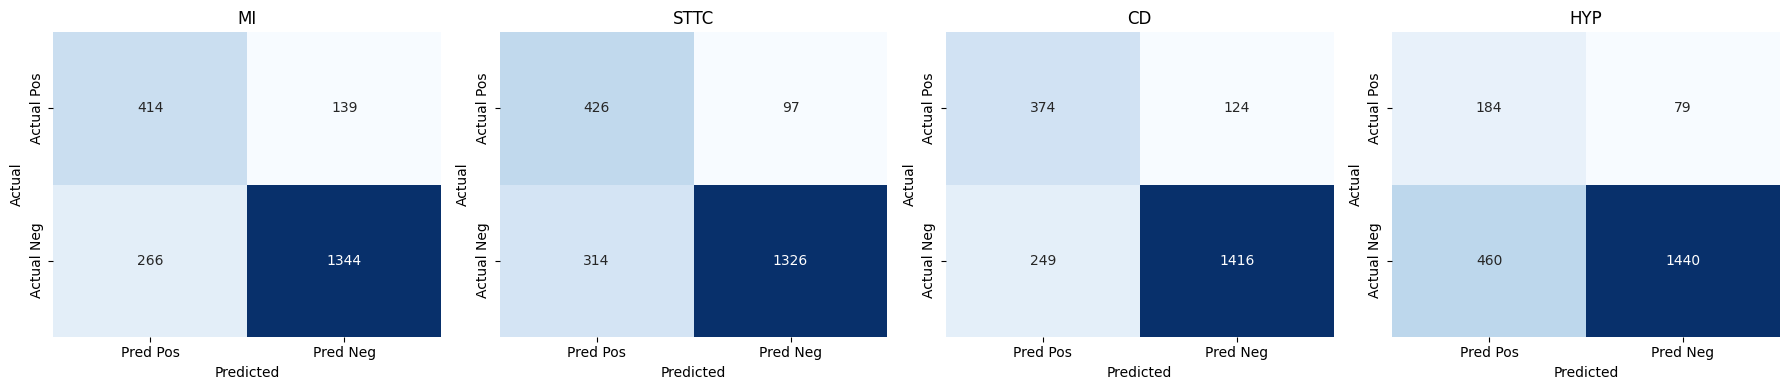

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

class_names = ["MI", "STTC", "CD", "HYP"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, ax in enumerate(axes):
    tn, fp, fn, tp = confusion_matrix(
        labels[:, i], preds[:, i]
    ).ravel()

    # Custom order: TP top-left
    cm_custom = np.array([
        [tp, fn],
        [fp, tn]
    ])

    sns.heatmap(
        cm_custom,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred Pos", "Pred Neg"],
        yticklabels=["Actual Pos", "Actual Neg"],
        ax=ax,
        cbar=False
    )

    ax.set_title(class_names[i])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Final Output

In [30]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import numpy as np

class_names = ["MI", "STTC", "CD", "HYP"]  # change if needed

sensitivities = []
specificities = []
f1s = []
aurocs = []

for i in range(labels.shape[1]):

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        labels[:, i], preds[:, i]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

    # F1
    f1s.append(f1_score(labels[:, i], preds[:, i]))

    # AUROC (use probabilities, not preds)
    try:
        aurocs.append(roc_auc_score(labels[:, i], probs[:, i]))
    except:
        aurocs.append(float("nan"))

sensitivities = np.array(sensitivities)
specificities = np.array(specificities)
f1s = np.array(f1s)
aurocs = np.array(aurocs)

# Macro averages
macro_sens = np.mean(sensitivities)
macro_spec = np.mean(specificities)
macro_f1 = np.mean(f1s)
macro_auc = np.nanmean(aurocs)

# Micro averages
micro_f1 = f1_score(labels, preds, average="micro")
micro_auc = roc_auc_score(labels, probs, average="micro")

# For sensitivity/specificity micro:
tn, fp, fn, tp = confusion_matrix(
    labels.ravel(), preds.ravel()
).ravel()

micro_sens = tp / (tp + fn)
micro_spec = tn / (tn + fp)

# ==========================
# PRINT TABLE
# ==========================

print("=" * 65)
print("Test Results")
print("=" * 65)
print(f"{'Class':<8}{'Sensitivity':<12}{'Specificity':<12}{'F1-score':<10}{'AUROC':<10}")
print("-" * 65)

for i, name in enumerate(class_names):
    print(f"{name:<8}{sensitivities[i]:<12.4f}{specificities[i]:<12.4f}{f1s[i]:<10.4f}{aurocs[i]:<10.4f}")

print("-" * 65)
print(f"{'Macro':<8}{macro_sens:<12.4f}{macro_spec:<12.4f}{macro_f1:<10.4f}{macro_auc:<10.4f}")
print(f"{'Micro':<8}{micro_sens:<12.4f}{micro_spec:<12.4f}{micro_f1:<10.4f}{micro_auc:<10.4f}")
print("=" * 65)

Test Results
Class   Sensitivity Specificity F1-score  AUROC     
-----------------------------------------------------------------
MI      0.7486      0.8348      0.6715    0.8735    
STTC    0.8145      0.8085      0.6746    0.8954    
CD      0.7510      0.8505      0.6673    0.8785    
HYP     0.6996      0.7579      0.4057    0.7956    
-----------------------------------------------------------------
Macro   0.7534      0.8129      0.6048    0.8608    
Micro   0.7610      0.8109      0.6180    0.8357    


# Losses

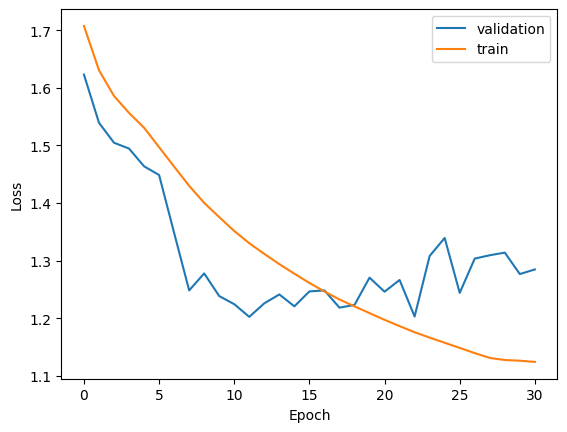

In [22]:
epochs_axis = torch.arange(1, epochs_run + 1)

plot_losses(
    valid_mean_losses,
    train_mean_losses,
    ylabel='Loss',
    name=f"training-validation-loss-{learning_rate}-{optimizer_name}"
)

# Explaining on the Example of one sample

In [40]:
from captum.attr import IntegratedGradients

model.eval()

X_sample, y_sample = next(iter(test_dataloader))
X_sample = X_sample.to(gpu_id)
class_to_explain=0 # 0=MI, 1=STTC, 2=CD, 3=HYP


In [41]:
with torch.backends.cudnn.flags(enabled=False):
    ig = IntegratedGradients(model)

    attributions, delta = ig.attribute(
        X_sample,
        target=class_to_explain,
        return_convergence_delta=True
    )

In [42]:
print(X_sample.shape)
print(attributions.shape)

torch.Size([1, 1000, 3])
torch.Size([1, 1000, 3])


In [43]:
attr = attributions.squeeze(0).detach().cpu()
x = X_sample.squeeze(0).detach().cpu()

## Feature Importance

In [44]:
num_features = attr.shape[1]
print("Number of features:", num_features)

Number of features: 3


In [45]:
feature_names = [f"Lead {i}" for i in range(1, num_features+1)]

In [46]:
feature_importance = attr.abs().sum(dim=0)

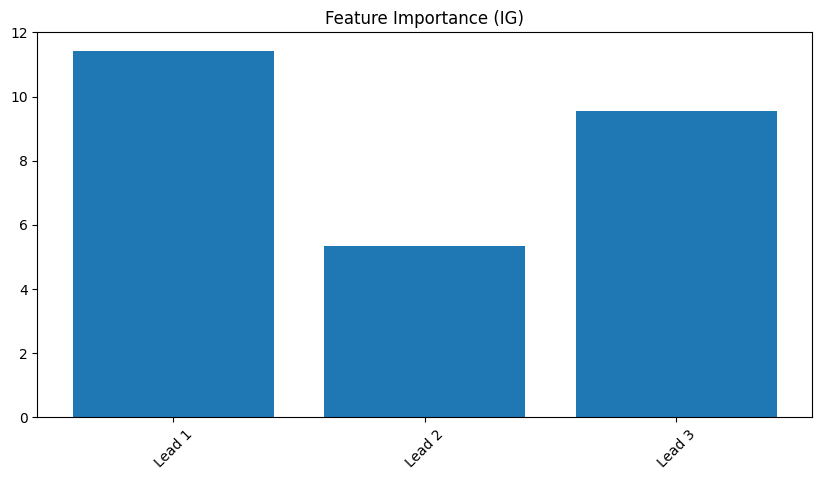

In [47]:
plt.figure(figsize=(10,5))
plt.bar(feature_names, feature_importance)
plt.xticks(rotation=45)
plt.title("Feature Importance (IG)")
plt.show()

## Time importance

In [48]:
X_sample.shape 

torch.Size([1, 1000, 3])

In [49]:
attr = attributions.squeeze(0).detach().cpu()
ecg = X_sample.squeeze(0).detach().cpu()

time_importance = attr.abs().sum(dim=1)  # sum over features

In [50]:
time_importance = time_importance / time_importance.max()

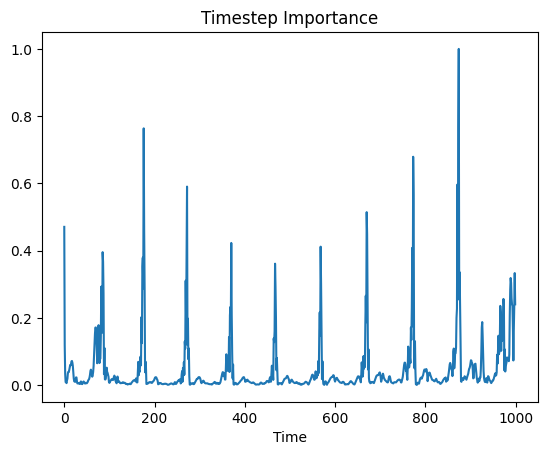

In [51]:
plt.plot(time_importance)
plt.title("Timestep Importance")
plt.xlabel("Time")
plt.show()

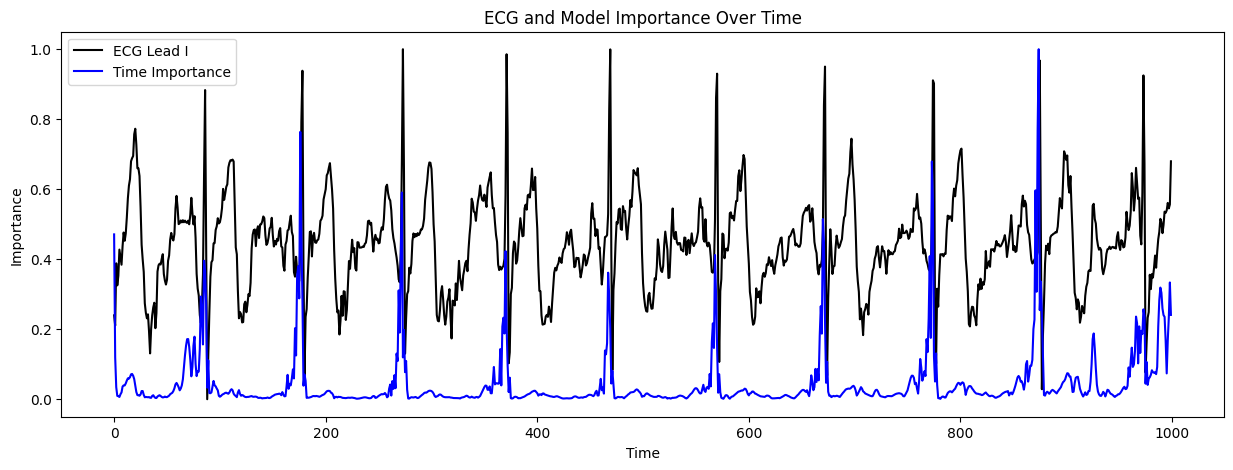

In [57]:
import matplotlib.pyplot as plt
import numpy as np

lead_idx = 0 # e.g. Lead I

signal = ecg[:, lead_idx]
importance = attr.abs().sum(dim=1)

# normalize importance
importance = importance / importance.max()

t = np.arange(len(signal))

fig, ax1 = plt.subplots(figsize=(15,5))

# ECG on left axis
ax1.plot(t, signal, label="ECG Lead I", color="black")
ax1.set_ylabel("Amplitude")
ax1.set_xlabel("Time")

ax1.plot(t, importance, label="Time Importance", color="blue")
ax1.set_ylabel("Importance")
ax1.set_xlabel("Time")
# Importance on right axis
#
plt.title("ECG and Model Importance Over Time")
plt.legend()
plt.show()

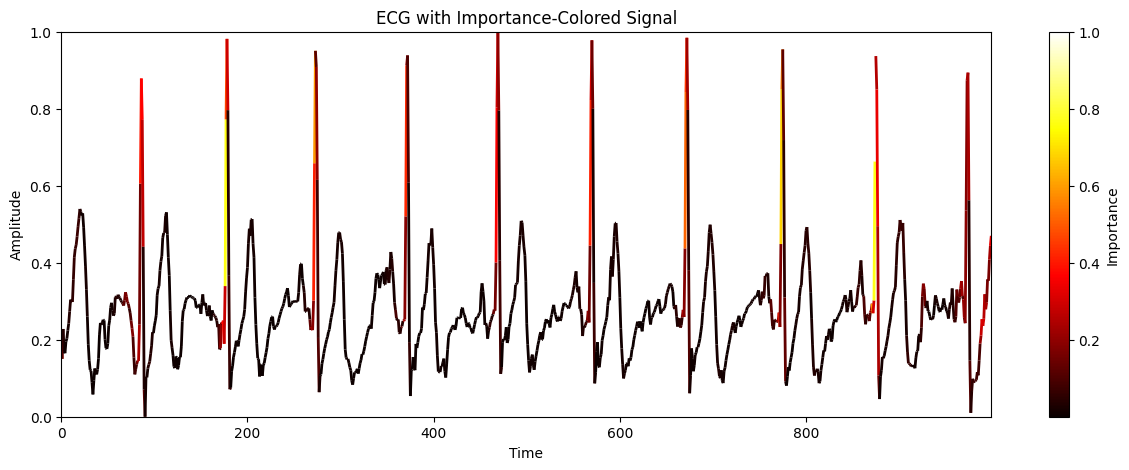

In [53]:
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt
import numpy as np

lead_idx = 1
signal = ecg[:, lead_idx]
importance = attr.abs().sum(dim=1)
importance = importance / importance.max()

t = np.arange(len(signal))

# Create line segments
points = np.array([t, signal]).T.reshape(-1,1,2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create colored line
lc = LineCollection(segments, cmap='hot')
lc.set_array(importance[:-1])
lc.set_linewidth(2)

fig, ax = plt.subplots(figsize=(15,5))
ax.add_collection(lc)
ax.set_xlim(t.min(), t.max())
ax.set_ylim(signal.min(), signal.max())

plt.colorbar(lc, label="Importance")
plt.title("ECG with Importance-Colored Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

## Full Heatmap

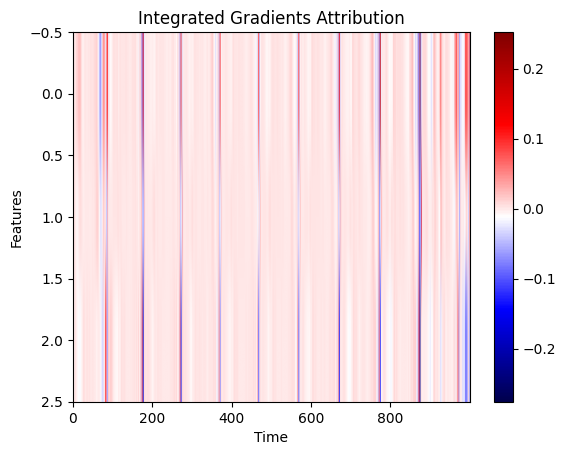

In [58]:
plt.imshow(attr.T, aspect="auto", cmap="seismic")
plt.colorbar()
plt.xlabel("Time")
plt.ylabel("Features")
plt.title("Integrated Gradients Attribution")
plt.show()

In [59]:
def evaluate_model(model, dataloader, threshold, device):
    model.eval()
    
    matrix = np.zeros((4, 4))  # [tp, fn, fp, tn] per class
    
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.cpu().numpy()
            
            logits = model(X)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            preds = (probs >= threshold).astype(int)
            
            matrix = compute_scores(y, preds, matrix)
    
    return matrix

Shape of ECG: (1000, 3)


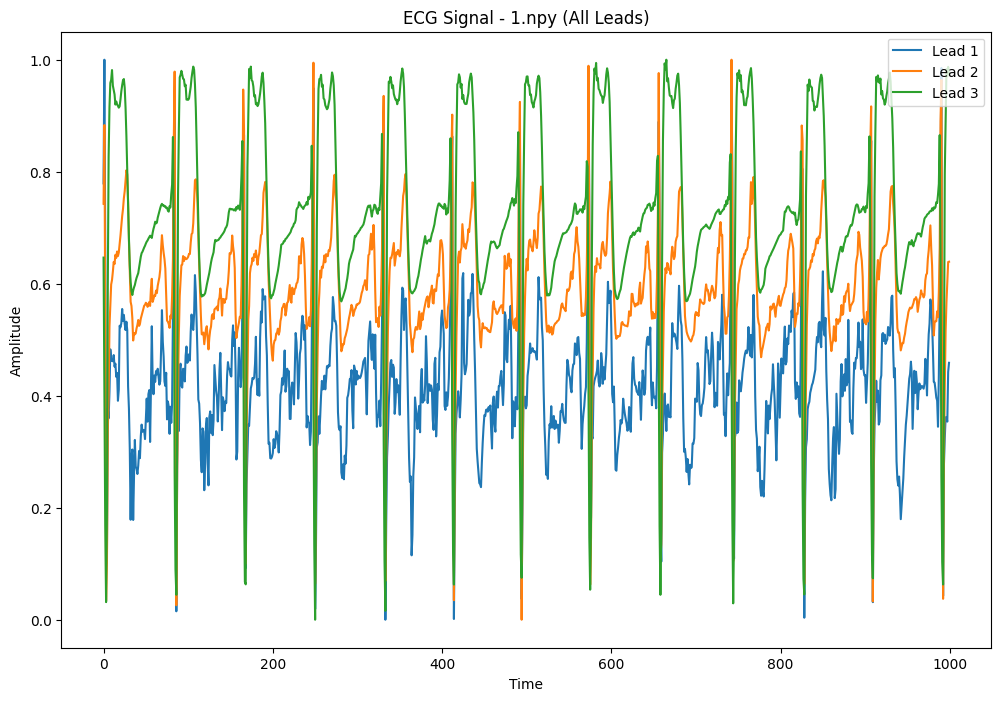

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# ---- CHANGE THIS PATH ----
path = "C:/Users/bauka/Downloads/RNNs/X_rnn_test//1.npy"

# Load ECG signal
ecg = np.load(path)

print("Shape of ECG:", ecg.shape)

# If signal is 1D → single lead
if len(ecg.shape) == 1:
    plt.figure(figsize=(12,4))
    plt.plot(ecg)
    plt.title("ECG Signal - 1.npy")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()

# If signal is 2D → multi-lead (e.g., 12 leads)
elif len(ecg.shape) == 2:
    plt.figure(figsize=(12,8))
    
    for i in range(ecg.shape[1]):  # iterate over leads
        plt.plot(ecg[:, i], label=f"Lead {i+1}")
    
    plt.title("ECG Signal - 1.npy (All Leads)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.legend(loc="upper right")
    plt.show()